<a href="https://colab.research.google.com/github/JosefinaMenta/Aprendizaje-Autom-tico-2026/blob/main/Clase%204/Ejercicio%202/notebook/Regresion_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Clasificación de uso de Sistema Operativo mediante Regresión Logística**

En esta notebook se aborda la construcción de un modelo de Regresión Logística para predecir el sistema operativo utilizado por los visitantes de un sitio web (clase), clasificándolos en Windows (0), Macintosh (1) o Linux (2).

Se utiliza el archivo provisto en la clase, con datos de entrada tomados de una web que utiliza Google Analytics. Comprende 4 características: Duración de la visita en Segundos (duracion), Cantidad de Páginas Vistas durante la Sesión (paginas), Cantidad de Acciones del usuario (acciones: click, scroll, uso de checkbox, sliders, etc.), Suma del Valor de las acciones (valor: cada acción lleva asociada una valoración de importancia).

In [2]:
import pandas as pd

df = pd.read_csv('usuarios_win_mac_lin.csv')

df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [9]:
# info general del dataset y tipos
print("--- ESTRUCTURA DEL DATASET ---")
df.info()

print("\n--- VALORES FALTANTES O NULOS ---")
print(df.isnull().sum())

print("\n--- DISTRIBUCIÓN DE CLASES (SISTEMAS OPERATIVOS) ---")
conteo_clases = df['clase'].value_counts().rename(index={0: 'Windows (0)', 1: 'Macintosh (1)', 2: 'Linux (2)'})
print(conteo_clases)

--- ESTRUCTURA DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB

--- VALORES FALTANTES O NULOS ---
duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64

--- DISTRIBUCIÓN DE CLASES (SISTEMAS OPERATIVOS) ---
clase
Windows (0)      86
Linux (2)        44
Macintosh (1)    40
Name: count, dtype: int64


El dataset no presenta valores nulos. Muestra una clara preponderancia de usuarios de Windows correspondiente a más de la mitad de las observaciones, mientras que Macintosh y Linux tienen una representación similar y menor.

In [3]:
X = df[['duracion', 'paginas', 'acciones', 'valor']]
y = df['clase']

In [4]:
from sklearn.model_selection import train_test_split

# división de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


In [5]:
from sklearn.linear_model import LogisticRegression

# entrenamiento
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Precisión en Test (Accuracy): 0.7353



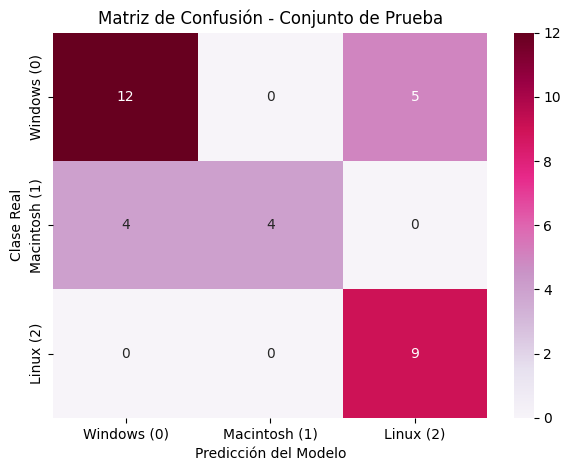


--- REPORTE DE CLASIFICACIÓN ---
               precision    recall  f1-score   support

  Windows (0)       0.75      0.71      0.73        17
Macintosh (1)       1.00      0.50      0.67         8
    Linux (2)       0.64      1.00      0.78         9

     accuracy                           0.74        34
    macro avg       0.80      0.74      0.73        34
 weighted avg       0.78      0.74      0.73        34



In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# predicción sobre el conjunto de prueba
y_pred_test = modelo.predict(X_test)

# cálculo de exactitud
exactitud = accuracy_score(y_test, y_pred_test)
print(f"Precisión en Test (Accuracy): {exactitud:.4f}\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del mapa de calor en tonos rosas
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test),
    annot=True,
    fmt='d',
    cmap='PuRd',  # Paleta de tonos púrpuras y rosas
    xticklabels=['Windows (0)', 'Macintosh (1)', 'Linux (2)'],
    yticklabels=['Windows (0)', 'Macintosh (1)', 'Linux (2)']
)

plt.title('Matriz de Confusión - Conjunto de Prueba')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.show()

# reporte detallado de clasificación
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_test, target_names=['Windows (0)', 'Macintosh (1)', 'Linux (2)']))

El modelo de Regresión Logística alcanzó una exactitud global del 73.5%, evidenciando cómo el volumen total del dataset condiciona la evaluación del modelo. Al ser 170 registros, la partición estándar del 20% para el conjunto de prueba deja un número acotado de observaciones (solo 8 de Macintosh), lo que amplifica el impacto de cada error en las métricas de desempeño. Esta dificultad se debe principalmente al solapamiento en los patrones de navegación entre Windows y Macintosh, cuyas métricas de uso resultan muy similares para el algoritmo, provocando que la mayor presencia de Windows en el entrenamiento sesgue la clasificación ante casos limítrofes. En contraste, los usuarios de Linux presentan hábitos de uso distintos que permiten al modelo detectarlos con total sensibilidad (Recall de 1.00), aunque arrastrando falsos positivos que bajan su precisión.
